# Nigeria-Ghana Sentinel-2 Dataset Comparison

This notebook checks whether the Nigeria Sentinel-2 feature space is comparable enough to Ghana to justify applying a Nigeria-trained road-condition model to Ghana roads.

The central question is **domain shift**: does a model trained on Nigeria see Ghana roads as similar examples, or are the satellite-index distributions different enough that transfer predictions should be treated as exploratory?

The comparison uses the shared Sentinel-2 index features available in both datasets:

- `NDVI`
- `NDMI`
- `NDBI`
- `NDWI`
- `BSI`

Nigeria also contains raw S2 bands and NIRTIMS condition/pavement attributes; Ghana contains OSM `fclass`. Those are documented separately because they are not directly shared features.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pyarrow.parquet as pq

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)


def find_repo_root(start=None, repo_name="Sentinel-FYP"):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repository root named {repo_name!r}")


def norm_id(series):
    return series.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)


ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
GHANA_PARQUET = DATA_DIR / "ghana_parquet"
NIGERIA_PARQUET = DATA_DIR / "nigeria_parquet"
NIRTIMS = DATA_DIR / "nirtims_2025_11_14"

IDX_COLS = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]

ghana_years = sorted(int(p.name.split("=")[1]) for p in GHANA_PARQUET.glob("year=*") if p.is_dir())
nigeria_years = sorted(int(p.name.split("=")[1]) for p in NIGERIA_PARQUET.glob("year=*") if p.is_dir())
COMMON_YEARS = sorted(set(ghana_years).intersection(nigeria_years))

# Use common years by default so differences are spatial/domain differences, not simply different time coverage.
# Change to e.g. MODEL_YEARS = [2023] for a single-year check.
MODEL_YEARS = COMMON_YEARS

PLOT_SAMPLE_PER_COUNTRY = 25_000
DOMAIN_SAMPLE_PER_COUNTRY = 40_000
RANDOM_STATE = 42

print(f"Repo root: {ROOT}")
print(f"Ghana S2 years: {ghana_years}")
print(f"Nigeria S2 years: {nigeria_years}")
print(f"Years compared: {MODEL_YEARS}")

Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP
Ghana S2 years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Nigeria S2 years: [2020, 2021, 2022, 2023, 2024, 2025]
Years compared: [2020, 2021, 2022, 2023]


## 1. Load Shared S2 Index Data

The raw datasets are quarterly road-level reductions from Google Earth Engine. Ghana roads are keyed by `osm_id`; Nigeria roads are keyed by `ROADCODE_N`.

Only the five common S2 indices are loaded for the main comparison. This keeps the transfer check aligned with the Ghana feature space.

In [2]:
def read_country_s2(country, root, years):
    frames = []
    for year in years:
        year_dir = root / f"year={year}"
        files = sorted(year_dir.glob("*.parquet"))
        if not files:
            print(f"Warning: no parquet files in {year_dir}")
            continue
        for path in files:
            available = pq.ParquetFile(path).schema_arrow.names
            if country == "Ghana":
                key_col = "osm_id"
                wanted = [key_col, "fclass", "quarter", *IDX_COLS]
            else:
                key_col = "ROADCODE_N"
                wanted = [key_col, "quarter", "SURFACECON", *IDX_COLS]
            wanted = [c for c in wanted if c in available]
            df = pd.read_parquet(path, columns=wanted).copy()
            df["country"] = country
            df["year"] = year
            df["road_id"] = norm_id(df[key_col])
            for col in IDX_COLS:
                df[col] = pd.to_numeric(df[col], errors="coerce")
            frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No S2 parquet data loaded for {country}")

    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=IDX_COLS, how="all").copy()
    out["quarter"] = out["quarter"].astype(str).str.strip()
    return out


ghana_q = read_country_s2("Ghana", GHANA_PARQUET, MODEL_YEARS)
nigeria_q = read_country_s2("Nigeria", NIGERIA_PARQUET, MODEL_YEARS)
s2_q = pd.concat([ghana_q, nigeria_q], ignore_index=True)

coverage = (
    s2_q.groupby("country")
    .agg(
        rows=("road_id", "size"),
        unique_roads=("road_id", "nunique"),
        years=("year", lambda s: sorted(s.unique().tolist())),
        quarters=("quarter", lambda s: sorted(s.unique().tolist())),
    )
    .reset_index()
)
display(coverage)
display(s2_q.groupby(["country", "year"]).agg(rows=("road_id", "size"), roads=("road_id", "nunique")))

,country,rows,unique_roads,years,quarters
0,Ghana,4563563,326546,"[2020, 2021, 2022, 2023]","[Q1, Q2, Q3, Q4]"
1,Nigeria,236287,4570,"[2020, 2021, 2022, 2023]","[Q1, Q2, Q3, Q4]"


rows   roads
country year                 
Ghana   2020  1230289  326546
        2021  1287790  326546
        2022  1016186  326546
        2023  1029298  326546
Nigeria 2020    61574    4570
        2021    61790    4570
        2022    58097    4570
        2023    54826    4570

## 2. Road-Level Feature Engineering

The transfer model will ultimately operate on road-level features, not individual quarterly rows. This section aggregates each road to comparable features: mean, standard deviation, minimum, maximum, range, and annual slope for each S2 index.

In [ ]:
def slope_from_row(row):
    y = row.dropna()
    if len(y) < 2:
        return 0.0
    x = y.index.astype(float).to_numpy()
    return float(np.polyfit(x, y.to_numpy(dtype=float), 1)[0])


def aggregate_road_features(df):
    # Important: Nigeria can contain multiple geometry/segment rows for the same road-quarter,
    # whereas Ghana is closer to one row per OSM road-quarter. Collapse first so count-based
    # artefacts do not become model features.
    rq = (
        df.groupby(["country", "road_id", "year", "quarter"], as_index=False)[IDX_COLS]
        .mean()
    )

    agg_spec = {}
    for col in IDX_COLS:
        agg_spec[f"{col}_mean"] = (col, "mean")
        agg_spec[f"{col}_std"] = (col, "std")
        agg_spec[f"{col}_min"] = (col, "min")
        agg_spec[f"{col}_max"] = (col, "max")

    road = (
        rq.groupby(["country", "road_id"], as_index=False)
        .agg(**agg_spec, n_quarters=("quarter", "count"), n_years=("year", "nunique"))
    )

    for col in IDX_COLS:
        road[f"{col}_range"] = road[f"{col}_max"] - road[f"{col}_min"]
        annual = rq.groupby(["country", "road_id", "year"])[col].mean().unstack("year")
        annual.columns = annual.columns.astype(int)
        trend = annual.apply(slope_from_row, axis=1).rename(f"{col}_annual_slope").reset_index()
        road = road.merge(trend, on=["country", "road_id"], how="left")
        road[f"{col}_annual_slope"] = road[f"{col}_annual_slope"].fillna(0)

    return road, rq


road_feats, road_quarter = aggregate_road_features(s2_q)
# Use only satellite-derived S2 features for domain-shift diagnostics. Coverage fields are
# reported separately because they are data-availability artefacts, not transferable predictors.
FEATURE_COLS = [
    c for c in road_feats.columns
    if c not in ["country", "road_id", "n_quarters", "n_years"]
]
COVERAGE_COLS = ["n_quarters", "n_years"]

print(f"Road-quarter rows after harmonising granularity: {len(road_quarter):,}")
print(f"Road-level rows: {len(road_feats):,}")
print(f"Satellite feature columns used for comparison: {len(FEATURE_COLS)}")
print("Coverage fields excluded from PCA/domain classifier:", COVERAGE_COLS)

display(
    road_feats.groupby("country").agg(
        roads=("road_id", "nunique"),
        median_quarters=("n_quarters", "median"),
        median_years=("n_years", "median"),
        min_quarters=("n_quarters", "min"),
        max_quarters=("n_quarters", "max"),
    )
)
display(road_feats.head())


## 3. Distribution Comparison

This section compares each index distribution between countries. Large shifts do not automatically prevent model transfer, but they mean Ghana predictions should be calibrated/validated rather than presented as ground truth.

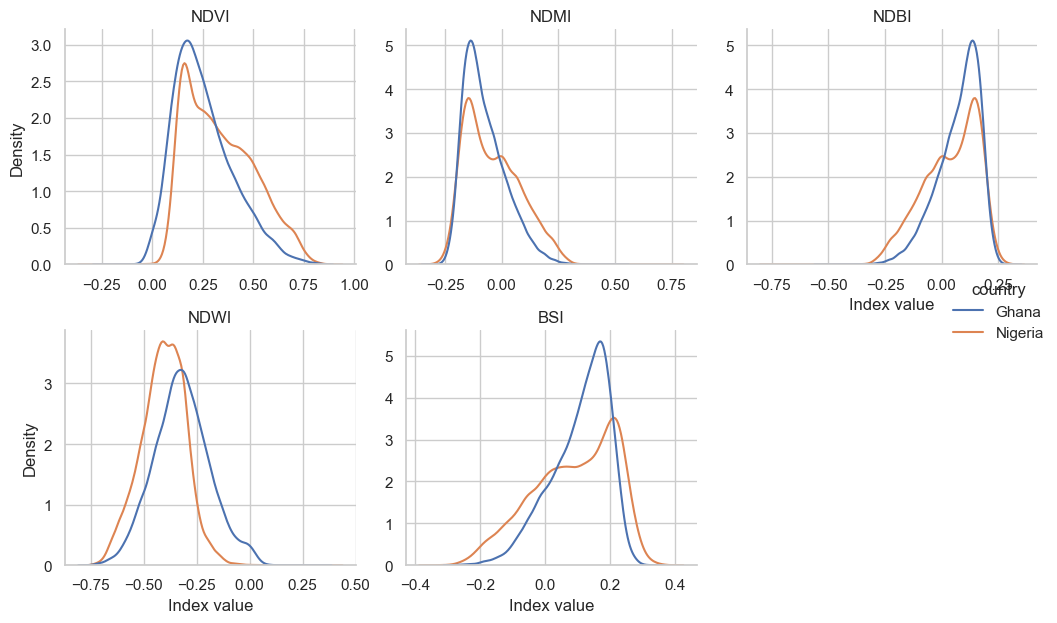

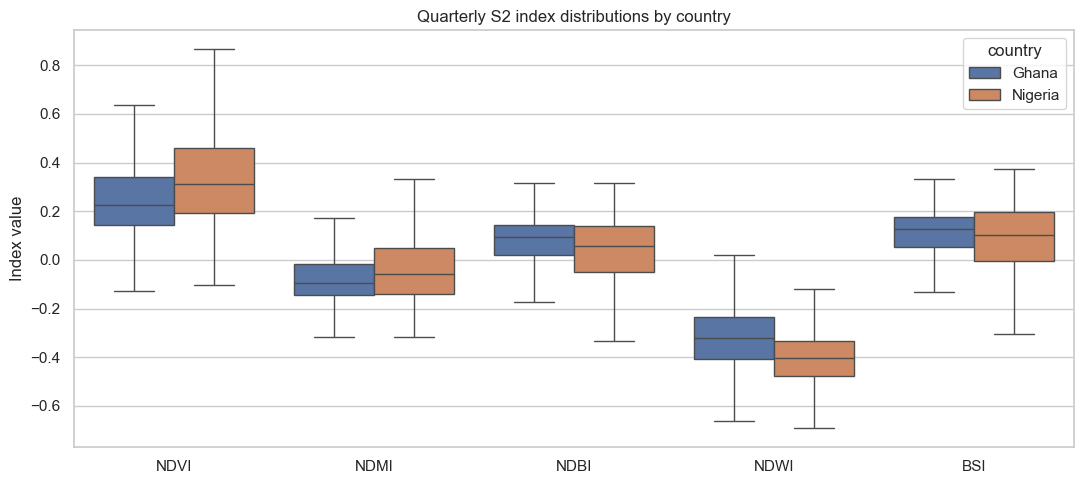

In [ ]:
def sample_for_plot(df, n_per_country=PLOT_SAMPLE_PER_COUNTRY):
    return (
        df.groupby("country", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), n_per_country), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )


plot_q = sample_for_plot(s2_q)
long_q = plot_q.melt(
    id_vars=["country", "year", "quarter", "road_id"],
    value_vars=IDX_COLS,
    var_name="index",
    value_name="value",
)

g = sns.displot(
    data=long_q,
    x="value",
    hue="country",
    col="index",
    col_wrap=3,
    kind="kde",
    common_norm=False,
    facet_kws={"sharex": False, "sharey": False},
    height=3.2,
)
g.set_titles("{col_name}")
g.set_axis_labels("Index value", "Density")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.boxplot(data=long_q, x="index", y="value", hue="country", showfliers=False)
plt.title("Quarterly S2 index distributions by country")
plt.xlabel("")
plt.ylabel("Index value")
plt.tight_layout()
plt.show()

,feature,ghana_mean,nigeria_mean,mean_difference_ghana_minus_nigeria,standardised_mean_difference,ghana_median,nigeria_median,ks_statistic
3,NDWI,-0.3186,-0.4067,0.0881,0.6612,-0.3218,-0.4008,0.2862
0,NDVI,0.2523,0.3376,-0.0852,-0.5654,0.2267,0.3124,0.1982
2,NDBI,0.0747,0.0383,0.0364,0.3826,0.0934,0.0559,0.1579
1,NDMI,-0.0747,-0.0383,-0.0364,-0.3826,-0.0934,-0.0559,0.1579
4,BSI,0.1079,0.0880,0.0199,0.2176,0.1262,0.1030,0.1296


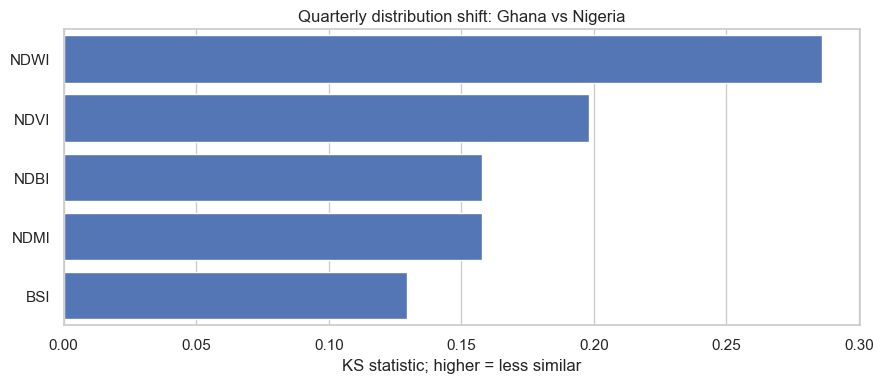

In [ ]:
def ks_statistic(a, b):
    a = np.sort(pd.Series(a).dropna().to_numpy())
    b = np.sort(pd.Series(b).dropna().to_numpy())
    if len(a) == 0 or len(b) == 0:
        return np.nan
    values = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, values, side="right") / len(a)
    cdf_b = np.searchsorted(b, values, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


rows = []
for col in IDX_COLS:
    gh = s2_q.loc[s2_q["country"] == "Ghana", col]
    ng = s2_q.loc[s2_q["country"] == "Nigeria", col]
    pooled_std = pd.concat([gh, ng]).std()
    rows.append(
        {
            "feature": col,
            "ghana_mean": gh.mean(),
            "nigeria_mean": ng.mean(),
            "mean_difference_ghana_minus_nigeria": gh.mean() - ng.mean(),
            "standardised_mean_difference": (gh.mean() - ng.mean()) / pooled_std if pooled_std else np.nan,
            "ghana_median": gh.median(),
            "nigeria_median": ng.median(),
            "ks_statistic": ks_statistic(gh, ng),
        }
    )

shift_q = pd.DataFrame(rows).sort_values("ks_statistic", ascending=False)
display(shift_q)

plt.figure(figsize=(9, 4))
sns.barplot(data=shift_q, x="ks_statistic", y="feature", color="#4472C4")
plt.title("Quarterly distribution shift: Ghana vs Nigeria")
plt.xlabel("KS statistic; higher = less similar")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Road-Level Feature-Space Shift

The quarterly plots show raw index distributions. The road-level comparison is closer to the actual modelling setup because the classifier uses aggregated road features.

,feature,ghana_mean,nigeria_mean,standardised_mean_difference,ks_statistic
20,n_obs,13.9753,51.7039,-3.1079,0.7243
15,NDWI_max,-0.1350,-0.2426,0.8680,0.4200
14,NDWI_min,-0.4158,-0.5269,0.9045,0.4063
3,NDVI_max,0.3687,0.5301,-0.9391,0.3911
12,NDWI_mean,-0.3203,-0.3943,0.7273,0.3741
1,NDVI_std,0.0764,0.1001,-0.5810,0.3702
22,NDVI_range,0.2607,0.3618,-0.7343,0.3590
2,NDVI_min,0.1080,0.1682,-0.6178,0.3397
26,NDBI_range,0.1992,0.2617,-0.7670,0.3121
24,NDMI_range,0.1992,0.2617,-0.7670,0.3121


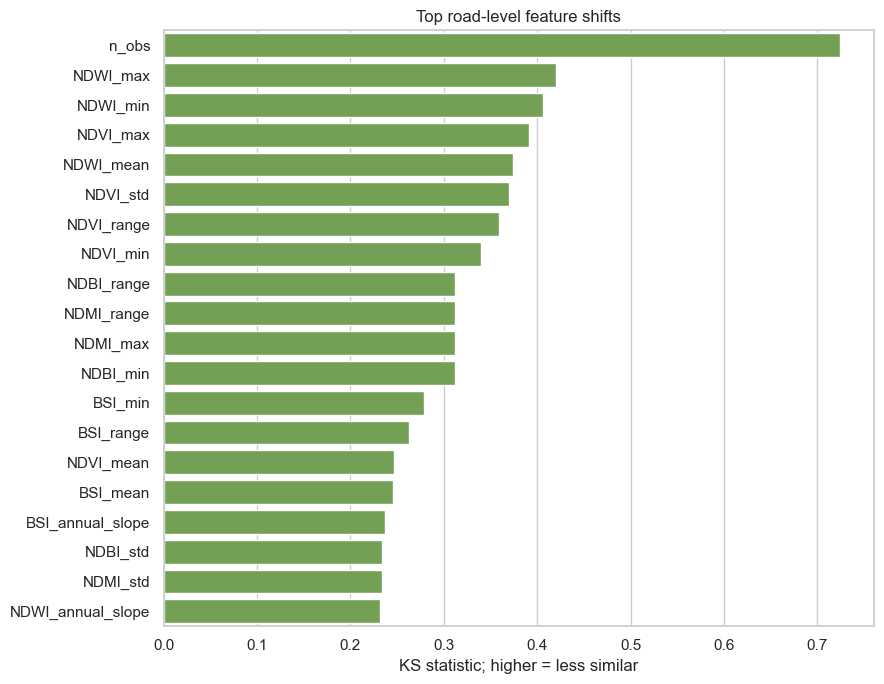

In [ ]:
rows = []
for col in FEATURE_COLS:
    gh = road_feats.loc[road_feats["country"] == "Ghana", col]
    ng = road_feats.loc[road_feats["country"] == "Nigeria", col]
    pooled_std = pd.concat([gh, ng]).std()
    rows.append(
        {
            "feature": col,
            "ghana_mean": gh.mean(),
            "nigeria_mean": ng.mean(),
            "standardised_mean_difference": (gh.mean() - ng.mean()) / pooled_std if pooled_std else np.nan,
            "ks_statistic": ks_statistic(gh, ng),
        }
    )

shift_road = pd.DataFrame(rows).sort_values("ks_statistic", ascending=False)
display(shift_road.head(20))

plt.figure(figsize=(9, 7))
sns.barplot(data=shift_road.head(20), x="ks_statistic", y="feature", color="#70AD47")
plt.title("Top road-level feature shifts")
plt.xlabel("KS statistic; higher = less similar")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. PCA Overlap

PCA gives a visual check of whether Ghana and Nigeria roads occupy similar regions of the shared S2 feature space. Strong separation suggests the Nigeria model may be learning country-specific satellite context rather than transferable road-condition signal.

PCA explained variance: PC1=0.435, PC2=0.199


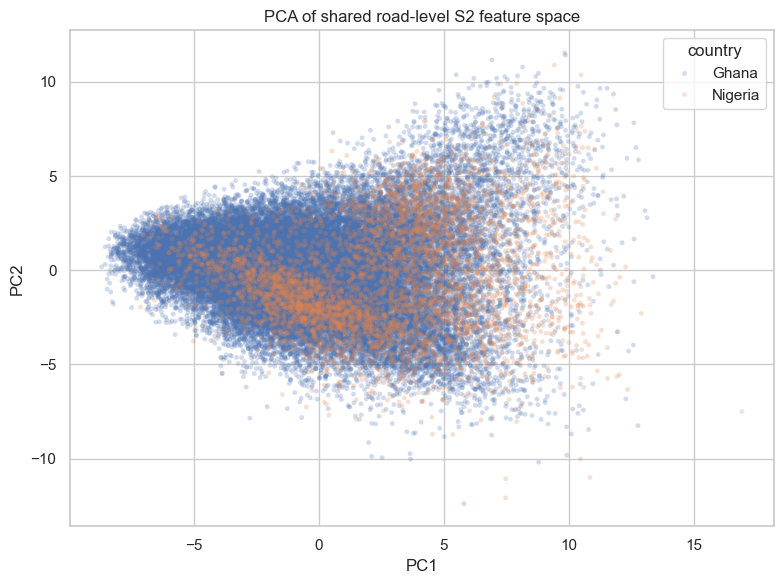

In [ ]:
balanced = (
    road_feats.groupby("country", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), DOMAIN_SAMPLE_PER_COUNTRY), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

X = balanced[FEATURE_COLS]
y_country = balanced["country"].values

pca_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
    ]
)
pca_xy = pca_pipe.fit_transform(X)
pca_df = pd.DataFrame(pca_xy, columns=["PC1", "PC2"])
pca_df["country"] = y_country

explained = pca_pipe.named_steps["pca"].explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]:.3f}, PC2={explained[1]:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="country",
    alpha=0.25,
    s=12,
    linewidth=0,
)
plt.title("PCA of shared road-level S2 feature space")
plt.tight_layout()
plt.show()

## 6. Domain Classifier Diagnostic

This is a compact test for transfer risk. A model is trained to predict whether a road feature vector comes from Ghana or Nigeria. If country can be predicted very accurately from the same S2 features, then the two domains are substantially different.

Interpretation:

- near `0.50` accuracy/AUC: countries are hard to distinguish; transfer is more plausible.
- `0.70-0.85`: moderate domain shift; transfer should be validated/calibrated.
- `>0.85`: strong domain shift; direct transfer predictions should be treated as exploratory.

Domain classifier accuracy: 0.983
Domain classifier ROC-AUC:  0.994
              precision    recall  f1-score   support

     Nigeria      0.958     0.876     0.915      4570
       Ghana      0.986     0.996     0.991     40000

    accuracy                          0.983     44570
   macro avg      0.972     0.936     0.953     44570
weighted avg      0.983     0.983     0.983     44570



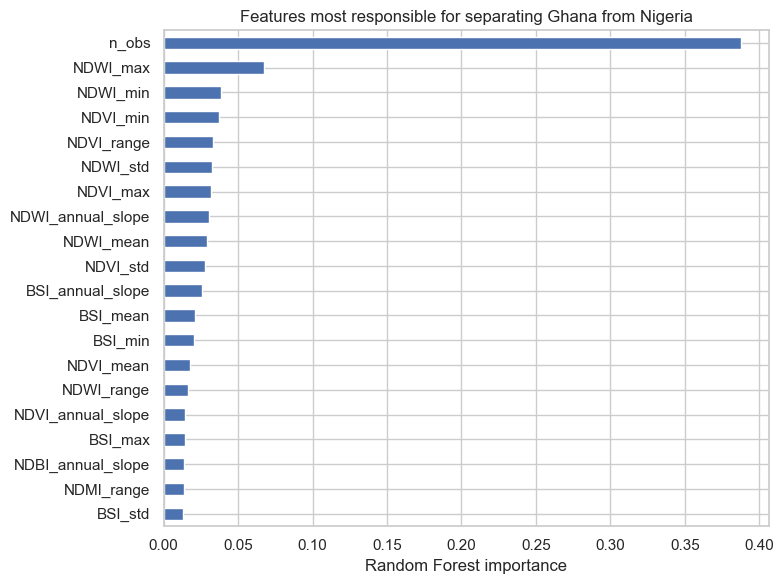

In [ ]:
domain_df = balanced.copy()
X = domain_df[FEATURE_COLS]
y = (domain_df["country"] == "Ghana").astype(int).values

domain_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pred = cross_val_predict(domain_model, X, y, cv=cv, method="predict")
proba = cross_val_predict(domain_model, X, y, cv=cv, method="predict_proba")[:, 1]

print(f"Domain classifier accuracy: {accuracy_score(y, pred):.3f}")
print(f"Domain classifier ROC-AUC:  {roc_auc_score(y, proba):.3f}")
print(classification_report(y, pred, target_names=["Nigeria", "Ghana"], digits=3))

domain_model.fit(X, y)
rf = domain_model.named_steps["rf"]
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
imp.head(20).sort_values().plot(kind="barh")
plt.title("Features most responsible for separating Ghana from Nigeria")
plt.xlabel("Random Forest importance")
plt.tight_layout()
plt.show()

## 7. Metadata and Surface-Composition Check

The satellite feature space is only one transfer issue. The Nigeria binary result is strongest on **paved roads**, so the Ghana application should ideally be restricted to roads that Layer 1 predicts as paved, or to Ghana roads with OSM surface evidence of paving.

This section compares available metadata:

- Ghana: OSM `fclass` from the GEE road asset.
- Nigeria: NIRTIMS pavement type, if the shapefile is available.

These are not equivalent variables, but they reveal whether the candidate transfer populations are structurally different.

In [ ]:
ghana_meta = (
    ghana_q[["road_id", "fclass"]]
    .dropna()
    .drop_duplicates()
)

print("Ghana OSM functional class distribution:")
display(
    ghana_meta["fclass"]
    .value_counts(normalize=True)
    .rename("share")
    .mul(100)
    .round(2)
    .to_frame()
)

try:
    road_pave = pd.DataFrame()
    import geopandas as gpd

    road_pave = gpd.read_file(NIRTIMS / "RoadPavement.shp")
    road_pave["ROADCODE_N"] = norm_id(road_pave["ROADCODE"])
    road_pave["PAVETYPE"] = road_pave["PAVETYPE"].astype(str).str.strip().str.upper()
    pave_map = {
        "EARTHEN": "Earthen",
        "GRAVEL": "Gravel",
        "ASPHALT CONCRETE": "Asphalt",
        "DBST": "SurfaceDressing",
        "SBST": "SurfaceDressing",
        "CONCRETE": "Concrete",
    }
    road_pave["pave_type"] = road_pave["PAVETYPE"].map(pave_map).fillna("Other")
    nigeria_pave = (
        road_pave.groupby("ROADCODE_N")["pave_type"]
        .agg(lambda s: s.value_counts().idxmax())
        .reset_index()
        .rename(columns={"ROADCODE_N": "road_id"})
    )
    print("\nNigeria NIRTIMS pavement type distribution:")
    display(
        nigeria_pave["pave_type"]
        .value_counts(normalize=True)
        .rename("share")
        .mul(100)
        .round(2)
        .to_frame()
    )
except Exception as exc:
    nigeria_pave = pd.DataFrame()
    print(f"Nigeria pavement shapefile could not be loaded: {exc}")

Ghana OSM functional class distribution:


,share
fclass,
residential,78.8200
service,10.9100
unclassified,7.0300
tertiary,1.4600
secondary,0.7300
trunk,0.5600
primary,0.4900



Nigeria NIRTIMS pavement type distribution:


,share
pave_type,
Earthen,72.9100
Asphalt,17.3700
Gravel,5.1000
SurfaceDressing,3.5700
Concrete,0.7100
Other,0.3400


## 8. Nigeria Paved Subset vs Ghana Candidate Roads

The paved-only Nigeria model should be transferred to Ghana only after a Ghana paved-road filter is defined. This notebook does not apply the model yet, but it prepares the comparison:

- Nigeria paved roads are selected using NIRTIMS pavement type.
- Ghana candidate roads are shown by OSM `fclass`; if a Layer 1 Ghana prediction table is later added, replace this with `predicted_surface == paved`.

Nigeria paved roads with S2 features: 965
Ghana roads with S2 features: 326,546


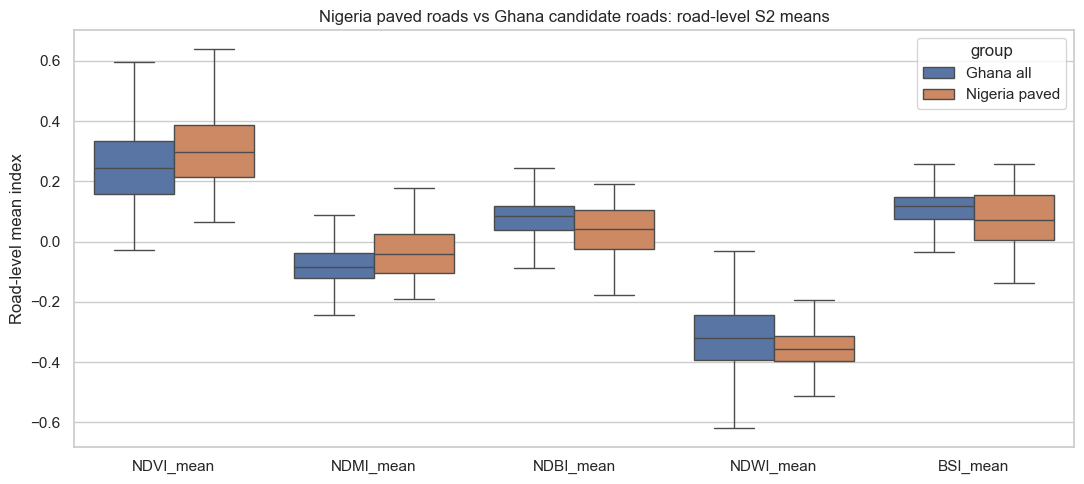

In [ ]:
if not nigeria_pave.empty:
    paved_types = ["Asphalt", "Concrete", "SurfaceDressing"]
    nigeria_paved_ids = set(nigeria_pave.loc[nigeria_pave["pave_type"].isin(paved_types), "road_id"])
    nigeria_paved_feats = road_feats[
        (road_feats["country"] == "Nigeria") & (road_feats["road_id"].isin(nigeria_paved_ids))
    ].copy()

    ghana_feats = road_feats[road_feats["country"] == "Ghana"].copy()

    print(f"Nigeria paved roads with S2 features: {len(nigeria_paved_feats):,}")
    print(f"Ghana roads with S2 features: {len(ghana_feats):,}")

    subset_df = pd.concat(
        [
            nigeria_paved_feats.assign(group="Nigeria paved"),
            ghana_feats.assign(group="Ghana all"),
        ],
        ignore_index=True,
    )

    subset_sample = (
        subset_df.groupby("group", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), PLOT_SAMPLE_PER_COUNTRY), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )
    subset_long = subset_sample.melt(
        id_vars=["group", "road_id"],
        value_vars=[f"{c}_mean" for c in IDX_COLS],
        var_name="feature",
        value_name="value",
    )

    plt.figure(figsize=(11, 5))
    sns.boxplot(data=subset_long, x="feature", y="value", hue="group", showfliers=False)
    plt.title("Nigeria paved roads vs Ghana candidate roads: road-level S2 means")
    plt.xlabel("")
    plt.ylabel("Road-level mean index")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping paved subset comparison because Nigeria pavement data was not loaded.")

## 9. Transfer Interpretation Checklist

Use the executed outputs to decide how to frame the Ghana application:

- If S2 distributions overlap and the domain classifier is weak after excluding coverage/count fields, direct Nigeria-to-Ghana transfer is more defensible.
- If the domain classifier remains strong using only S2 index features, present Ghana predictions as an exploratory transfer test rather than validated condition estimates.
- If Nigeria paved roads differ strongly from Ghana all-road features, first apply the Ghana Layer 1 paved/unpaved classifier and transfer only to predicted paved roads.
- If S2 + S1 or other features are used in Nigeria, Ghana must have the same feature engineering before applying the model.
- Any Ghana prediction should be clearly labelled as **model-inferred condition risk**, not measured road condition, unless Ghana ground truth is later obtained.